In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler , OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier ,GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,precision_score, recall_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import shap
import joblib

In [56]:
df = pd.read_csv('../data/heart.csv')


In [57]:
df.shape


(920, 16)

In [58]:
df.head(920)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [60]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 3. Preprocessing
### 3.1 Features & Target

In [61]:
# id column useless hai — drop karo
X = df.drop(columns=['num', 'id']).copy()
y = df['num'].copy()

# Binary classification: 0 = No disease, 1 = Disease (num > 0)
y = (y > 0).astype(int)

print(f'Features : {X.shape}')
print(f'\nTarget distribution:')
print(y.value_counts().rename({0: 'No Disease (0)', 1: 'Disease (1)'}))

Features : (920, 14)

Target distribution:
num
Disease (1)       509
No Disease (0)    411
Name: count, dtype: int64


In [62]:
print('=== NaN per column ===')
nan_counts = X.isnull().sum()
print(nan_counts[nan_counts > 0])
print(f'\nTotal NaNs in X : {X.isnull().sum().sum()}')
print(f'Total NaNs in y : {y.isnull().sum()}')
print(f'\nColumn dtypes:')
print(X.dtypes)

=== NaN per column ===
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

Total NaNs in X : 1759
Total NaNs in y : 0

Column dtypes:
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
dtype: object


In [63]:
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns  : {num_cols}')
print(f'Categoric columns: {cat_cols}')

# Numeric → median (outliers se safe)
if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Categorical → most frequent
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

print(f'\n✅ NaN after imputation: {X.isnull().sum().sum()}')

Numeric columns  : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categoric columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

✅ NaN after imputation: 0


In [64]:
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print('✅ Encoding complete')
print(f'\nFinal dtypes:')
print(X.dtypes)
print(f'\nX shape: {X.shape}')
X.head()

✅ Encoding complete

Final dtypes:
age         float64
sex           int64
dataset       int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal          int64
dtype: object

X shape: (920, 14)


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63.0,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0
1,67.0,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1
2,67.0,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2
3,37.0,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1
4,41.0,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Train disease rate : {y_train.mean()*100:.1f}%  |  Test : {y_test.mean()*100:.1f}%')

Train : (736, 14)  |  Test : (184, 14)
Train disease rate : 55.3%  |  Test : 55.4%


In [66]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('✅ Models defined')

✅ Models defined


In [67]:
print(f"{'Model':<25}  {'CV ROC-AUC':>12}  {'±':>6}")
print('-' * 48)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f'{name:<25} {scores.mean():>12.4f} {scores.std():>6.4f}')

Model                        CV ROC-AUC       ±
------------------------------------------------
Logistic Regression             0.8835 0.0281
Random Forest                   0.8857 0.0180
Gradient Boosting               0.8862 0.0218
XGBoost                         0.8657 0.0236


In [68]:
scoring      = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
full_results = {}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=True)
    full_results[name] = {
        'Accuracy'      : scores['test_accuracy'].mean(),
        'Precision'     : scores['test_precision'].mean(),
        'Recall'        : scores['test_recall'].mean(),
        'F1 Score'      : scores['test_f1'].mean(),
        'ROC AUC'       : scores['test_roc_auc'].mean(),
        'Train Accuracy': scores['train_accuracy'].mean(),
        'Overfit Gap'   : scores['train_accuracy'].mean() - scores['test_accuracy'].mean()
    }

results_df = pd.DataFrame(full_results).T.sort_values('ROC AUC', ascending=False)
print(results_df.round(4))

                     Accuracy  Precision  Recall  F1 Score  ROC AUC  \
Gradient Boosting      0.8120     0.8157  0.8527    0.8334   0.8862   
Random Forest          0.8217     0.8291  0.8547    0.8413   0.8857   
Logistic Regression    0.8250     0.8470  0.8350    0.8406   0.8835   
XGBoost                0.7935     0.8063  0.8253    0.8146   0.8657   

                     Train Accuracy  Overfit Gap  
Gradient Boosting             0.916       0.1041  
Random Forest                 1.000       0.1783  
Logistic Regression           0.825      -0.0000  
XGBoost                       1.000       0.2065  


In [69]:
# Best model per metric
core_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
print('🏆 Best model per metric:')
for metric in core_metrics:
    best = results_df[metric].idxmax()
    print(f'  {metric:12}: {best} ({results_df.loc[best, metric]:.4f})')

# Overfit check
print('\n🔍 Overfit check (train - test accuracy):')
for name in results_df.index:
    gap  = results_df.loc[name, 'Overfit Gap']
    flag = '⚠️  Overfit' if gap > 0.05 else '✅ OK'
    print(f'  {name:<25}: {gap:.4f}  {flag}')

🏆 Best model per metric:
  Accuracy    : Logistic Regression (0.8250)
  Precision   : Logistic Regression (0.8470)
  Recall      : Random Forest (0.8547)
  F1 Score    : Random Forest (0.8413)
  ROC AUC     : Gradient Boosting (0.8862)

🔍 Overfit check (train - test accuracy):
  Gradient Boosting        : 0.1041  ⚠️  Overfit
  Random Forest            : 0.1783  ⚠️  Overfit
  Logistic Regression      : -0.0000  ✅ OK
  XGBoost                  : 0.2065  ⚠️  Overfit


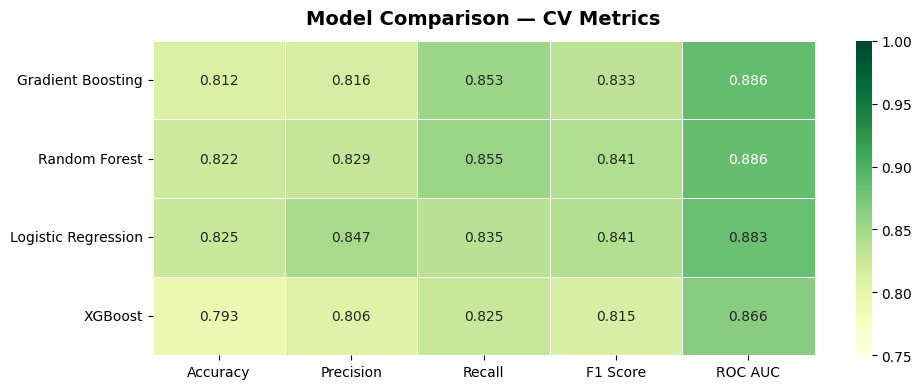

In [70]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = results_df[core_metrics].astype(float)
sns.heatmap(plot_df, annot=True, fmt='.3f',
            cmap='YlGn', vmin=0.75, vmax=1.0,
            linewidths=0.5, ax=ax)
ax.set_title('Model Comparison — CV Metrics', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

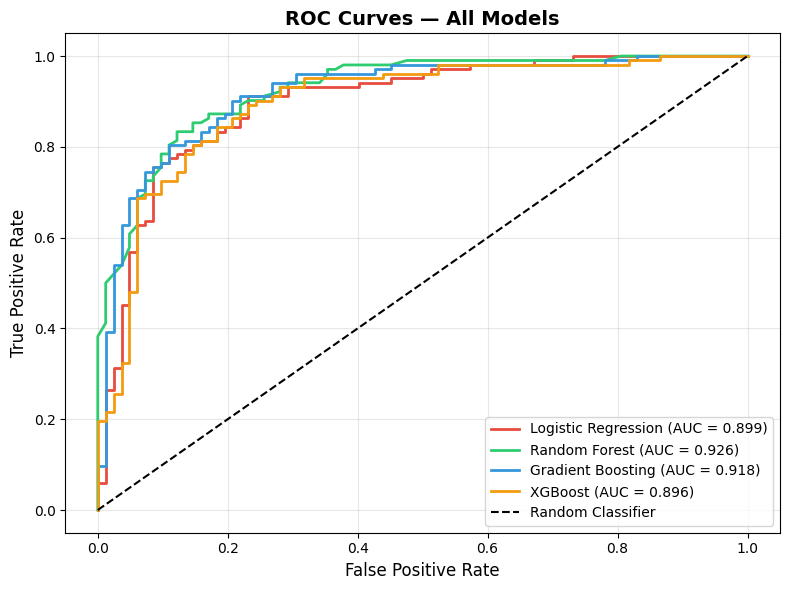

In [71]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train, y_train)
    y_prob      = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

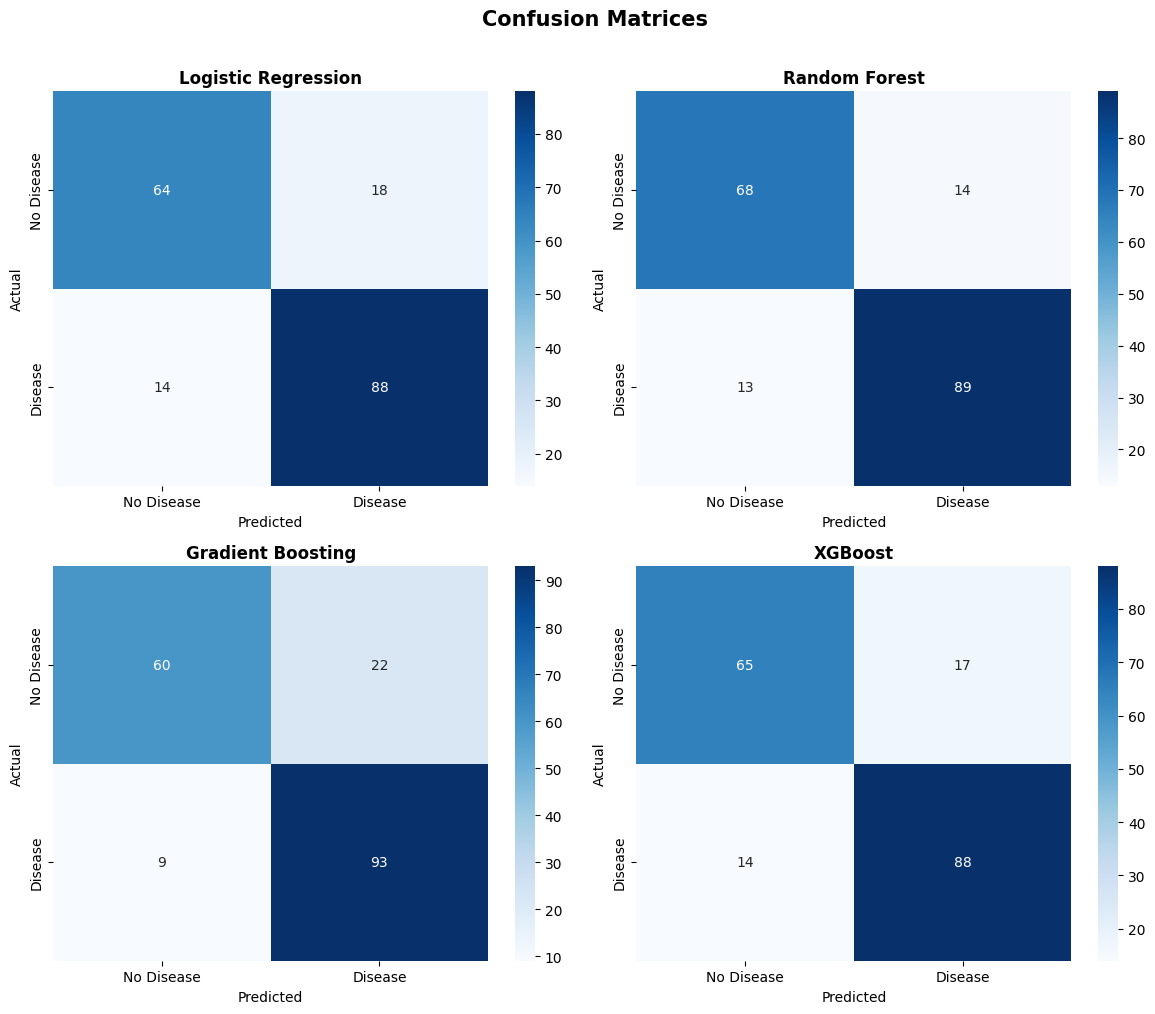

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                ax=axes[idx])
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred,
                                target_names=['No Disease', 'Disease']))


  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.82      0.78      0.80        82
     Disease       0.83      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184


  Random Forest
              precision    recall  f1-score   support

  No Disease       0.84      0.83      0.83        82
     Disease       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


  Gradient Boosting
              precision    recall  f1-score   support

  No Disease       0.87      0.73      0.79        82
     Disease       0.81      0.91      0.86       102

    accuracy                           0.83       184
   macro avg       0.84      0.82      0.83       184
weighted avg 

C:\Users\abdul\AppData\Local\Temp\ipykernel_14812\523194023.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', ax=ax)


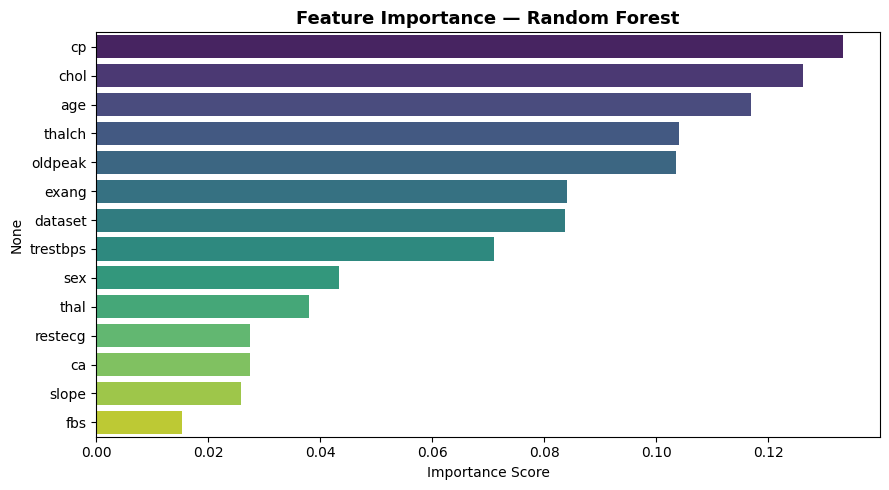


Top 5 features:
cp         0.133260
chol       0.126207
age        0.116803
thalch     0.104036
oldpeak    0.103553
dtype: float64


In [74]:
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', ax=ax)
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features:')
print(feat_imp.head())

In [85]:
os.makedirs('../models', exist_ok=True)

# ROC AUC se best model select karo
best_name  = results_df['ROC AUC'].idxmax()
best_model = models[best_name]
best_model.fit(X_train, y_train)

joblib.dump(best_model, '../models/best_model.pkl')

# Verify
loaded     = joblib.load('../models/best_model.pkl')
test_score = roc_auc_score(y_test, loaded.predict_proba(X_test)[:, 1])

print(f'✅ Best Model   : {best_name}')
print(f'✅ Test ROC AUC : {test_score:.4f}')
print(f'✅ Saved to     : ../models/best_model.pkl')

✅ Best Model   : Gradient Boosting
✅ Test ROC AUC : 0.9185
✅ Saved to     : ../models/best_model.pkl
